In [21]:
import pandas as pd
import numpy as np
import shap
import xgboost as xgb
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [22]:
def load_and_aggregate_data(filepath):
    print(f"Loading data from {filepath}...")
    df = pd.read_csv(filepath)
    
    features_to_agg = ['LST', 'MNDWI', 'NDBI', 'NDVI', 'dist_coast', 'elevation', 'slope']
    
    for col in features_to_agg:
        if col not in df.columns:
            raise ValueError(f"{col} not in CSV")
            
    if 'grid_id' not in df.columns or 'year' not in df.columns:
        raise ValueError("grid_id or year not in CSV")

    df_agg = df.groupby(['grid_id','year'])[features_to_agg].median().reset_index()
    df_agg = df_agg.dropna()
    print(f"Aggregated data shape: {df_agg.shape}")
    return df_agg

filepath = 'uhi_data_multiyear_export.csv'
try:
    df = load_and_aggregate_data(filepath)
except FileNotFoundError:
    print(f"File {filepath} not found. Run the EE export script first.")


Loading data from uhi_data_multiyear_export.csv...
Aggregated data shape: (735, 9)


Data overview:


,grid_id,year,LST,MNDWI,NDBI,NDVI,dist_coast,elevation,slope
0,"693,12529",2019,28.912354,-0.510984,-0.354286,0.826087,6795.366068,480.0,12.713199
1,"693,12529",2022,28.025377,-0.357523,-0.330789,0.686820,6795.366068,480.0,12.713199
2,"693,12529",2025,29.237066,-0.561470,-0.357798,0.866705,6795.366068,480.0,12.713199
3,"693,12530",2019,28.135609,-0.467343,-0.324559,0.797215,6855.821022,480.0,22.671031
4,"693,12530",2022,28.768797,-0.444718,-0.368525,0.785555,6855.821022,480.0,22.671031



Summary statistics:


,year,LST,MNDWI,NDBI,NDVI,dist_coast,elevation,slope
count,735.000000,735.000000,735.000000,735.000000,735.000000,735.000000,735.000000,735.000000
mean,2022.024490,36.896010,-0.434212,-0.068758,0.486303,2341.581190,153.986395,6.869522
std,2.451035,4.368577,0.078026,0.196931,0.257000,1519.216850,106.856689,5.481558
min,2019.000000,25.962602,-0.610464,-0.424823,-0.014248,0.000000,0.000000,0.000000
25%,2019.000000,33.202823,-0.476183,-0.269474,0.248529,1126.454615,88.000000,3.105018
50%,2022.000000,37.551399,-0.433758,-0.026965,0.459937,2232.042092,125.000000,4.719417
75%,2025.000000,40.286242,-0.399673,0.107332,0.748235,3315.711707,219.000000,8.465295
max,2025.000000,48.777886,0.134068,0.541883,0.894561,6855.821022,499.000000,35.637498


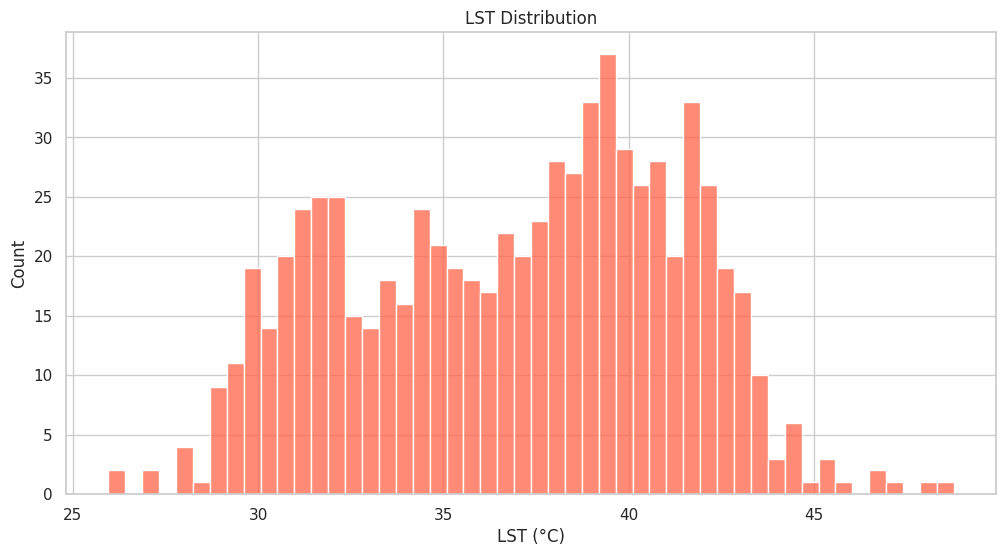

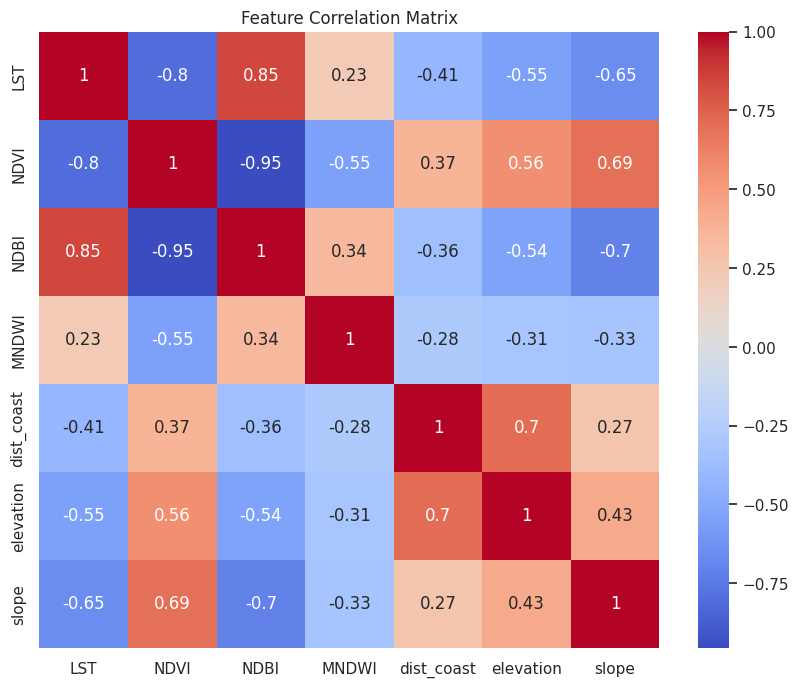

In [23]:
print("Data overview:")
display(df.head())
print("\nSummary statistics:")
display(df.describe())

plt.figure(figsize=(12,6))
sns.histplot(df['LST'], bins=50, color='tomato')
plt.title("LST Distribution")
plt.xlabel("LST (°C)")
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df[['LST','NDVI','NDBI','MNDWI','dist_coast','elevation','slope']].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()


In [24]:
feature_cols = ['MNDWI','NDBI','NDVI','dist_coast','elevation','slope','year']
target_col = 'LST'

X = df[feature_cols]
y = df[target_col]
groups = df['grid_id']


In [25]:
def train_and_evaluate(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    return rmse, r2


In [26]:
n_splits = 5
gss = GroupShuffleSplit(n_splits=n_splits, test_size=0.2, random_state=42)

results = {
    'LR': {'rmse': [], 'r2': []},
    'RF': {'rmse': [], 'r2': []},
    'XGB': {'rmse': [], 'r2': []}
}

shap_results_xgb = []
shap_results_rf = []
perm_results_xgb = []
perm_results_rf = []


In [27]:
for i, (train_idx, test_idx) in enumerate(gss.split(X, y, groups)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    train_grids = set(groups.iloc[train_idx])
    test_grids = set(groups.iloc[test_idx])
    if not train_grids.isdisjoint(test_grids):
        print("WARNING: Spatial leakage detected!")

    lr = Pipeline([('scaler', StandardScaler()), ('regressor', LinearRegression())])
    rmse, r2 = train_and_evaluate(lr, X_train, X_test, y_train, y_test)
    results['LR']['rmse'].append(rmse)
    results['LR']['r2'].append(r2)

    rf = RandomForestRegressor(n_estimators=100, random_state=42+i, n_jobs=-1)
    rmse, r2 = train_and_evaluate(rf, X_train, X_test, y_train, y_test)
    results['RF']['rmse'].append(rmse)
    results['RF']['r2'].append(r2)

    explainer_rf = shap.Explainer(rf)
    shap_vals_rf = explainer_rf(X_test)
    shap_results_rf.append(np.abs(shap_vals_rf.values).mean(axis=0))
    perm_rf = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42+i, n_jobs=-1)
    perm_results_rf.append(perm_rf.importances_mean)

    xgbr = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=0, n_jobs=-1)
    rmse, r2 = train_and_evaluate(xgbr, X_train, X_test, y_train, y_test)
    results['XGB']['rmse'].append(rmse)
    results['XGB']['r2'].append(r2)

    explainer_xgb = shap.Explainer(xgbr)
    shap_vals_xgb = explainer_xgb(X_test)
    shap_results_xgb.append(np.abs(shap_vals_xgb.values).mean(axis=0))
    perm_xgb = permutation_importance(xgbr, X_test, y_test, n_repeats=10, random_state=42+i, n_jobs=-1)
    perm_results_xgb.append(perm_xgb.importances_mean)


In [28]:
print("=== Stability Check Results (Mean ± Std) ===")
for model_name, metrics in results.items():
    print(f"{model_name}: RMSE {np.mean(metrics['rmse']):.4f} ± {np.std(metrics['rmse']):.4f}, R2 {np.mean(metrics['r2']):.4f} ± {np.std(metrics['r2']):.4f}")


=== Stability Check Results (Mean ± Std) ===
LR: RMSE 2.1115 ± 0.1221, R2 0.7626 ± 0.0339
RF: RMSE 1.6637 ± 0.2358, R2 0.8509 ± 0.0394
XGB: RMSE 1.8136 ± 0.2718, R2 0.8228 ± 0.0486



=== XGBoost SHAP Feature Importance ===


NDBI          1.654159
NDVI          1.476491
elevation     0.417600
dist_coast    0.382361
slope         0.216471
MNDWI         0.178753
dtype: float32

Std Dev (instability):


NDBI          0.603910
NDVI          0.498827
elevation     0.104502
MNDWI         0.063172
slope         0.052036
dist_coast    0.049498
dtype: float32


=== XGBoost Permutation Feature Importance ===


NDBI          0.398497
NDVI          0.234282
elevation     0.074955
dist_coast    0.048820
MNDWI         0.006431
slope         0.004276
dtype: float64

Std Dev (instability):


NDBI          0.138945
NDVI          0.125409
elevation     0.039442
MNDWI         0.010104
slope         0.009849
dist_coast    0.009747
dtype: float64

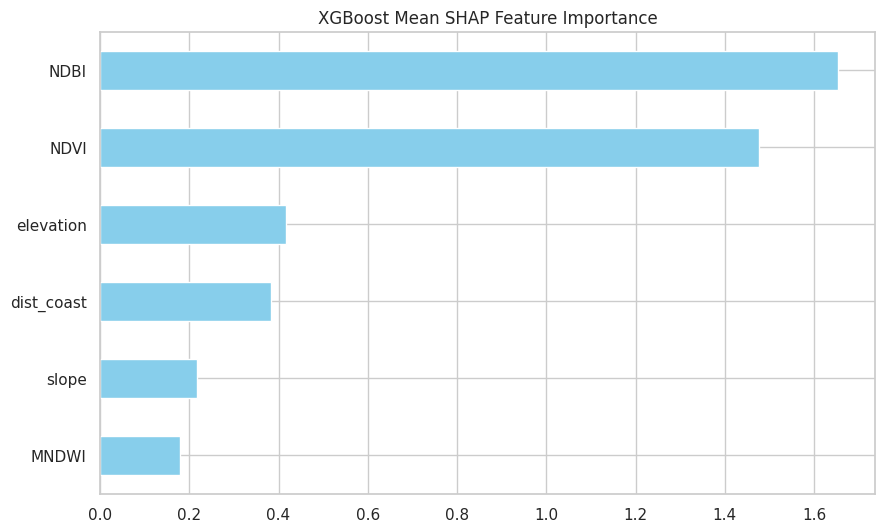

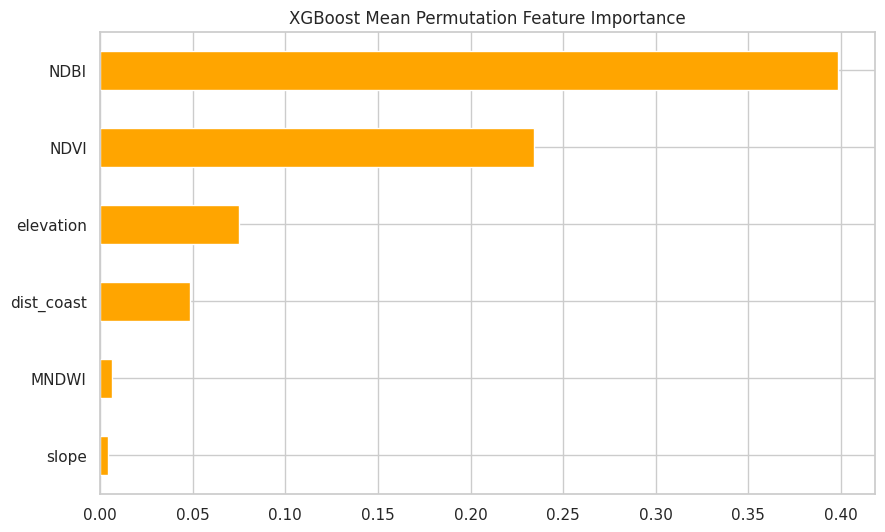


=== Random Forest SHAP Feature Importance ===


NDBI          1.902438
NDVI          1.364630
dist_coast    0.335497
elevation     0.273593
slope         0.110801
MNDWI         0.107002
dtype: float64

Std Dev (instability):


NDBI          0.575405
NDVI          0.434652
dist_coast    0.036817
slope         0.033663
elevation     0.030888
MNDWI         0.023827
dtype: float64


=== Random Forest Permutation Feature Importance ===


NDBI          0.502073
NDVI          0.190190
dist_coast    0.050892
elevation     0.041473
slope         0.007051
MNDWI         0.006188
dtype: float64

Std Dev (instability):


NDBI          0.147859
NDVI          0.117056
dist_coast    0.014224
elevation     0.012126
slope         0.005033
MNDWI         0.002512
dtype: float64

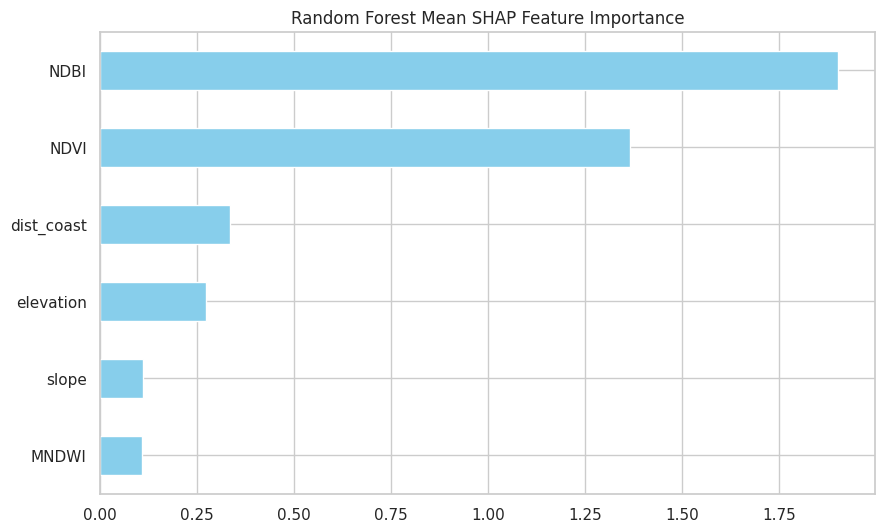

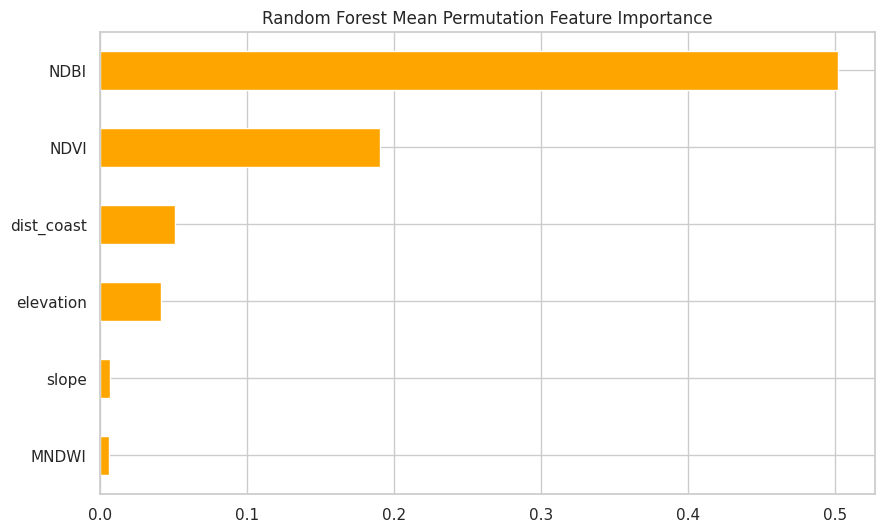

In [29]:
def feature_importance_analysis(shap_list, perm_list, features, model_name):
    shap_df = pd.DataFrame(shap_list, columns=features)
    perm_df = pd.DataFrame(perm_list, columns=features)
    if 'year' in shap_df.columns:
        shap_df = shap_df.drop(columns=['year'])
        perm_df = perm_df.drop(columns=['year'])

    print(f"\n=== {model_name} SHAP Feature Importance ===")
    display(shap_df.mean().sort_values(ascending=False))
    print(f"Std Dev (instability):")
    display(shap_df.std().sort_values(ascending=False))

    print(f"\n=== {model_name} Permutation Feature Importance ===")
    display(perm_df.mean().sort_values(ascending=False))
    print(f"Std Dev (instability):")
    display(perm_df.std().sort_values(ascending=False))

    plt.figure(figsize=(10,6))
    shap_df.mean().sort_values().plot(kind='barh', color='skyblue')
    plt.title(f'{model_name} Mean SHAP Feature Importance')
    plt.show()

    plt.figure(figsize=(10,6))
    perm_df.mean().sort_values().plot(kind='barh', color='orange')
    plt.title(f'{model_name} Mean Permutation Feature Importance')
    plt.show()

feature_importance_analysis(shap_results_xgb, perm_results_xgb, X.columns, "XGBoost")
feature_importance_analysis(shap_results_rf, perm_results_rf, X.columns, "Random Forest")



=== Multiple Linear Regression (Interpretability Focus) ===

Mean Coefficients (scaled features):
      Feature  Coefficient    StdDev
0        NDBI     3.104819  0.085862
5        year     0.674130  0.015362
2       slope    -0.430541  0.040212
1   elevation    -0.350458  0.036637
3  dist_coast    -0.316271  0.054247
4       MNDWI    -0.159556  0.028132

Mean RMSE: 2.1083 ± 0.1232
Mean R²:   0.7635 ± 0.0321


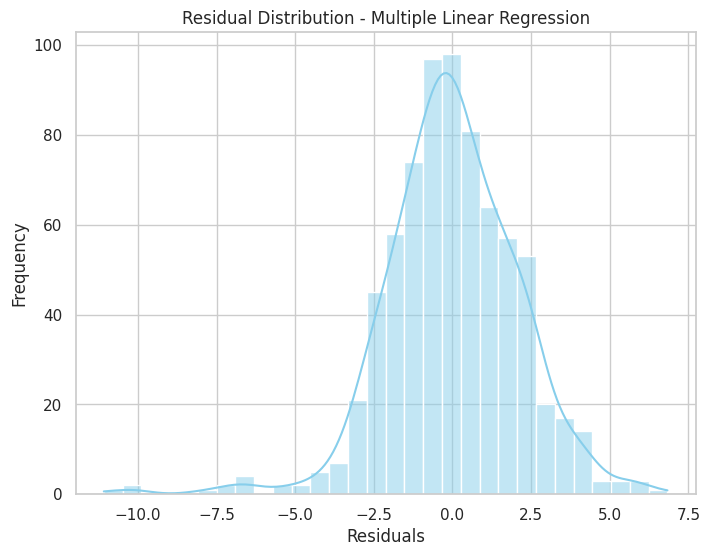

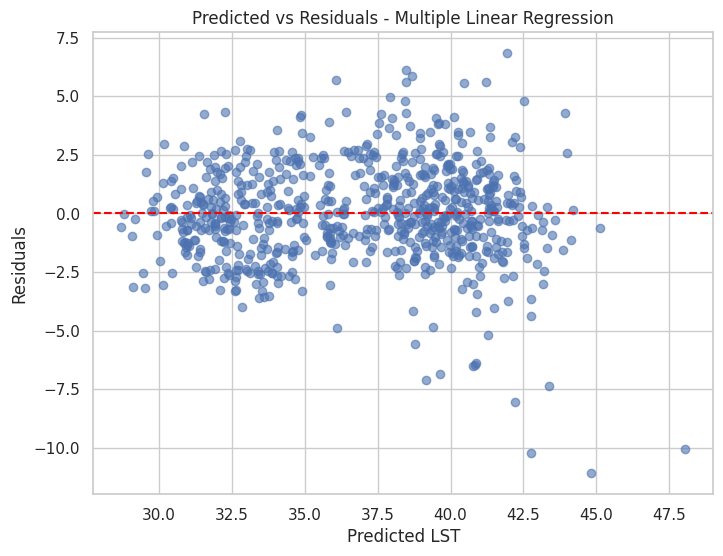

In [30]:
    # === MULTIPLE LINEAR REGRESSION FOR INTERPRETABILITY ===
    print("\n=== Multiple Linear Regression (Interpretability Focus) ===")
    
    # Drop one of the collinear features for clarity
    mlr_features = ['NDBI', 'elevation', 'slope', 'dist_coast', 'MNDWI', 'year']
    X_mlr = df[mlr_features]
    y_mlr = df[target_col]
    
    rmse_mlr_list = []
    r2_mlr_list = []
    coef_list = []

    for train_idx, test_idx in gss.split(X_mlr, y_mlr, groups):
        X_train, X_test = X_mlr.iloc[train_idx], X_mlr.iloc[test_idx]
        y_train, y_test = y_mlr.iloc[train_idx], y_mlr.iloc[test_idx]

        # Scale features for interpretability
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        lr_model = LinearRegression()
        lr_model.fit(X_train_scaled, y_train)
        y_pred = lr_model.predict(X_test_scaled)

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        rmse_mlr_list.append(rmse)
        r2_mlr_list.append(r2)
        coef_list.append(lr_model.coef_)

    # Aggregate coefficients and metrics
    coef_mean = np.mean(coef_list, axis=0)
    coef_std = np.std(coef_list, axis=0)
    coef_df = pd.DataFrame({
        'Feature': mlr_features,
        'Coefficient': coef_mean,
        'StdDev': coef_std
    }).sort_values(by='Coefficient', key=abs, ascending=False)

    print("\nMean Coefficients (scaled features):")
    print(coef_df)

    print(f"\nMean RMSE: {np.mean(rmse_mlr_list):.4f} ± {np.std(rmse_mlr_list):.4f}")
    print(f"Mean R²:   {np.mean(r2_mlr_list):.4f} ± {np.std(r2_mlr_list):.4f}")

    # === Visualization of residuals ===
    lr_model_final = LinearRegression()
    scaler_final = StandardScaler()
    X_scaled_final = scaler_final.fit_transform(X_mlr)
    lr_model_final.fit(X_scaled_final, y_mlr)
    y_pred_full = lr_model_final.predict(X_scaled_final)
    residuals = y_mlr - y_pred_full

    plt.figure(figsize=(8,6))
    sns.histplot(residuals, bins=30, kde=True, color='skyblue')
    plt.xlabel("Residuals")
    plt.ylabel("Frequency")
    plt.title("Residual Distribution - Multiple Linear Regression")
    plt.show()

    plt.figure(figsize=(8,6))
    plt.scatter(y_pred_full, residuals, alpha=0.6)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel("Predicted LST")
    plt.ylabel("Residuals")
    plt.title("Predicted vs Residuals - Multiple Linear Regression")
    plt.show()



=== Multiple Linear Regression (Interpretability Focus) ===

Mean Coefficients (scaled features):
      Feature  Coefficient    StdDev
0        NDVI    -3.398956  0.089202
4       MNDWI    -1.128207  0.068484
2       slope    -0.604509  0.037896
5        year     0.510830  0.028224
3  dist_coast    -0.482494  0.075844
1   elevation    -0.212379  0.020892

Mean RMSE: 2.1753 ± 0.1137
Mean R²:   0.7474 ± 0.0396


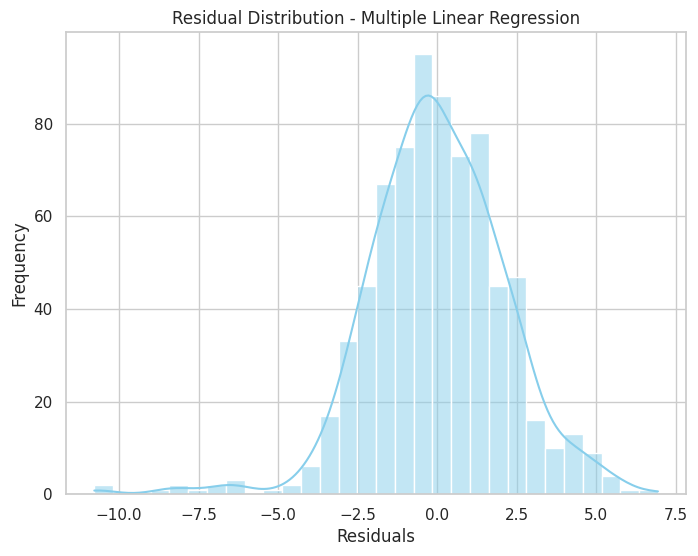

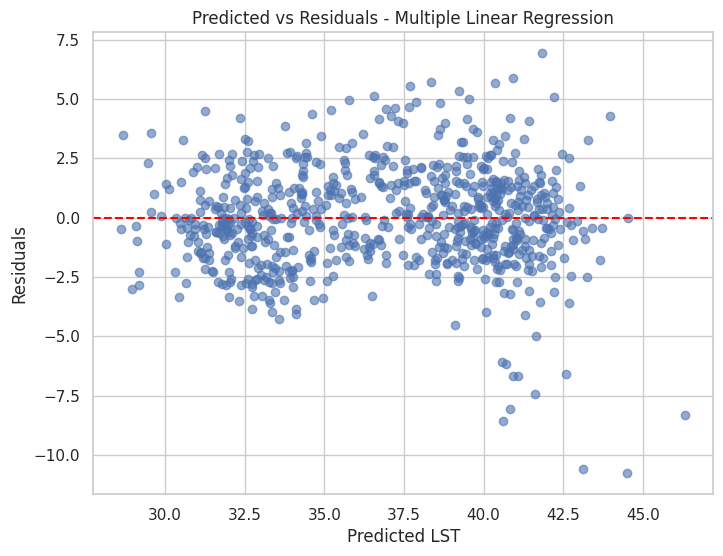

In [31]:
    # === MULTIPLE LINEAR REGRESSION FOR INTERPRETABILITY ===
    print("\n=== Multiple Linear Regression (Interpretability Focus) ===")
    
    # Drop one of the collinear features for clarity
    mlr_features = ['NDVI', 'elevation', 'slope', 'dist_coast', 'MNDWI', 'year']
    X_mlr = df[mlr_features]
    y_mlr = df[target_col]
    
    rmse_mlr_list = []
    r2_mlr_list = []
    coef_list = []

    for train_idx, test_idx in gss.split(X_mlr, y_mlr, groups):
        X_train, X_test = X_mlr.iloc[train_idx], X_mlr.iloc[test_idx]
        y_train, y_test = y_mlr.iloc[train_idx], y_mlr.iloc[test_idx]

        # Scale features for interpretability
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        lr_model = LinearRegression()
        lr_model.fit(X_train_scaled, y_train)
        y_pred = lr_model.predict(X_test_scaled)

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        rmse_mlr_list.append(rmse)
        r2_mlr_list.append(r2)
        coef_list.append(lr_model.coef_)

    # Aggregate coefficients and metrics
    coef_mean = np.mean(coef_list, axis=0)
    coef_std = np.std(coef_list, axis=0)
    coef_df = pd.DataFrame({
        'Feature': mlr_features,
        'Coefficient': coef_mean,
        'StdDev': coef_std
    }).sort_values(by='Coefficient', key=abs, ascending=False)

    print("\nMean Coefficients (scaled features):")
    print(coef_df)

    print(f"\nMean RMSE: {np.mean(rmse_mlr_list):.4f} ± {np.std(rmse_mlr_list):.4f}")
    print(f"Mean R²:   {np.mean(r2_mlr_list):.4f} ± {np.std(r2_mlr_list):.4f}")

    # === Visualization of residuals ===
    lr_model_final = LinearRegression()
    scaler_final = StandardScaler()
    X_scaled_final = scaler_final.fit_transform(X_mlr)
    lr_model_final.fit(X_scaled_final, y_mlr)
    y_pred_full = lr_model_final.predict(X_scaled_final)
    residuals = y_mlr - y_pred_full

    plt.figure(figsize=(8,6))
    sns.histplot(residuals, bins=30, kde=True, color='skyblue')
    plt.xlabel("Residuals")
    plt.ylabel("Frequency")
    plt.title("Residual Distribution - Multiple Linear Regression")
    plt.show()

    plt.figure(figsize=(8,6))
    plt.scatter(y_pred_full, residuals, alpha=0.6)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel("Predicted LST")
    plt.ylabel("Residuals")
    plt.title("Predicted vs Residuals - Multiple Linear Regression")
    plt.show()
